## Wind speed analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd

In [3]:
wind_fina=xr.open_dataset('data/wind_fina.nc')
wind_alfred=xr.open_dataset('data/wind_alfred.nc')
wind_baseline_first=xr.open_dataset('data/wind_base_firstperiod.nc')
wind_baseline_second=xr.open_dataset('data/wind_base_secondperiod.nc')
wind_baseline_third=xr.open_dataset('data/wind_base_thirdperiod.nc')

## Exclude cyclone periods

In [4]:
exclude_periods=[('2020-02-04', '2020-02-14'), ('2020-03-14', '2020-03-15'), ('2021-01-16', '2021-01-19'), ('2021-01-24', '2021-02-01'), ('2021-02-27', '2021-03-05'), ('2021-12-09', '2021-12-15'), ('2022-02-07', '2022-02-12')]

In [5]:
#exclude dates if in exclude_periods

def exclude_periods_from_ds(ds, exclude_periods):
    time = ds['time']

    # start with all True (keep everything)
    keep_mask = xr.ones_like(time, dtype=bool)

    for start, end in exclude_periods:
        start = np.datetime64(start)
        end = np.datetime64(end)

        keep_mask = keep_mask & ~((time >= start) & (time <= end))

    return ds.sel(time=keep_mask)

In [6]:
wind_baseline_first_clean  = exclude_periods_from_ds(
    wind_baseline_first, exclude_periods
)

wind_baseline_second_clean = exclude_periods_from_ds(
    wind_baseline_second, exclude_periods
)

wind_baseline_third_clean  = exclude_periods_from_ds(
    wind_baseline_third, exclude_periods
)


## Compute wind speeds

In [7]:
u_fina=wind_fina['eastward_wind']
v_fina=wind_fina['northward_wind']

u_alfred=wind_alfred['eastward_wind']
v_alfred=wind_alfred['northward_wind']

u_baseline_first=wind_baseline_first['eastward_wind']
v_baseline_first=wind_baseline_first['northward_wind']

u_baseline_second=wind_baseline_second['eastward_wind']
v_baseline_second=wind_baseline_second['northward_wind']

u_baseline_third=wind_baseline_third['eastward_wind']
v_baseline_third=wind_baseline_third['northward_wind']


wind_speed_fina=np.sqrt(u_fina**2+v_fina**2)
#print(wind_speed_fina) #data array with 3 dimensions (time, latitude, longitude). each subarray gives the wind speeds at different longitudes for one fixed latitude
wind_speed_alfred=np.sqrt(u_alfred**2+v_alfred**2)
wind_speed_baseline_first=np.sqrt(u_baseline_first**2+v_baseline_first**2)
wind_speed_baseline_second=np.sqrt(u_baseline_second**2+v_baseline_second**2)
wind_speed_baseline_third=np.sqrt(u_baseline_third**2+v_baseline_third**2)

In [8]:
#fixes the dimensions of the data array to be only time, by averaging over the spatial dimensions (latitude and longitude)
wind_ts_fina = wind_speed_fina.mean(dim=("latitude", "longitude"))
wind_ts_fina = wind_ts_fina.sel(time=slice("2011-12-01", "2012-01-31")) #selects only the time period of interest (during cyclone Fina)
print("Max wind speed during cyclone Fina:", wind_ts_fina.max().values, "m/s")

wind_ts_alfred = wind_speed_alfred.mean(dim=("latitude", "longitude"))
wind_ts_alfred = wind_ts_alfred.sel(time=slice("2025-02-01", "2025-03-31"))
print("Max wind speed during cyclone Alfred:", wind_ts_alfred.max().values, "m/s")

wind_ts_baseline_first = wind_speed_baseline_first.mean(dim=("latitude", "longitude"))
wind_ts_baseline_second = wind_speed_baseline_second.mean(dim=("latitude", "longitude"))
wind_ts_baseline_third = wind_speed_baseline_third.mean(dim=("latitude", "longitude"))


Max wind speed during cyclone Fina: 14.053050994873047 m/s
Max wind speed during cyclone Alfred: 23.83913803100586 m/s


## Average the baseline period

In [9]:
baseline_ts_list = [
    wind_ts_baseline_first,
    wind_ts_baseline_second,
    wind_ts_baseline_third,
]

def add_season_day(da):
    time = da.time.to_index()

    # Define November 1 of the relevant season
    season_start = time.map(
        lambda t: pd.Timestamp(t.year if t.month >= 11 else t.year - 1, 11, 1)
    )

    season_day = (time - season_start).days

    return da.assign_coords(season_day=("time", season_day))

baseline_seasonal_wind = [add_season_day(ts) for ts in baseline_ts_list]

baseline_all = xr.concat(baseline_seasonal_wind, dim="season")

baseline_mean_wind = (
    baseline_all
    .groupby("season_day")
    .mean(skipna=True)
)

wind_baseline_speed = xr.concat(    [        wind_speed_baseline_first,        wind_speed_baseline_second,        wind_speed_baseline_third,    ],    dim="time",)
#print(baseline_mean_wind)
print("Mean wind speed during baseline period:", baseline_mean_wind.mean().values, "m/s")

Mean wind speed during baseline period: 6.4010551650273175 m/s


## Plots

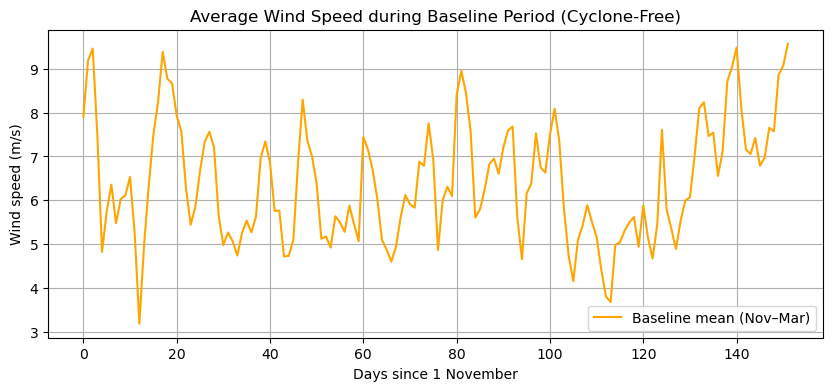

In [10]:

plt.figure(figsize=(10, 4))
plt.plot(
    baseline_mean_wind.season_day,
    baseline_mean_wind,
    label="Baseline mean (Nov–Mar)",
    color="orange"
)

plt.xlabel("Days since 1 November")
plt.ylabel("Wind speed (m/s)")
plt.title("Average Wind Speed during Baseline Period (Cyclone-Free)")
plt.grid(True)
plt.legend()
#save plot
plt.savefig("plots/baseline_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()


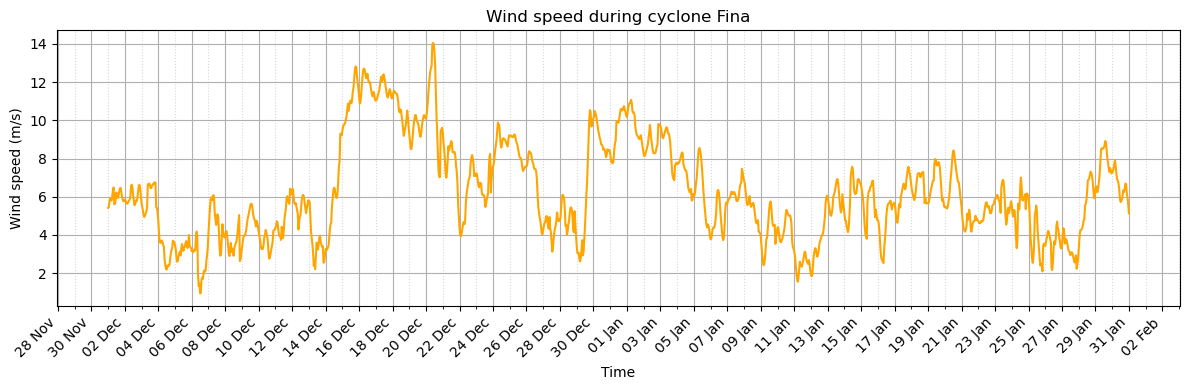

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_fina.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Fina")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/fina_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()



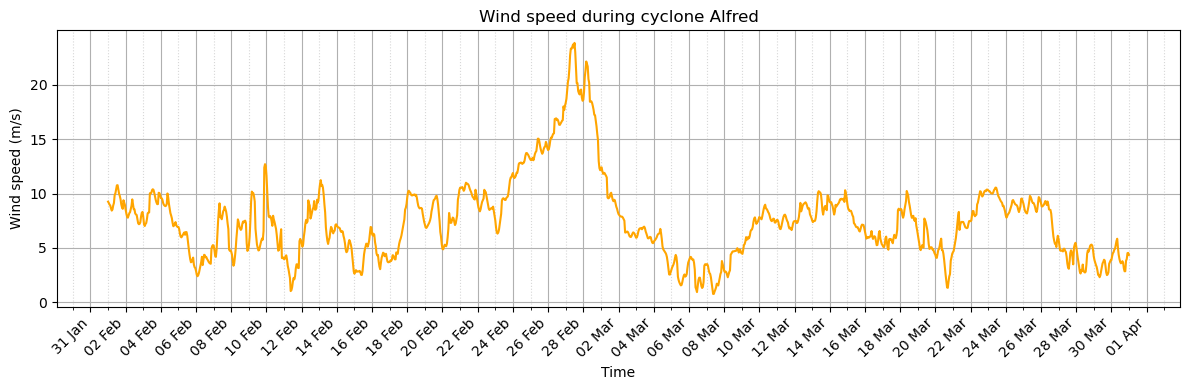

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax, color='orange')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/alfred_wind_speed.png", dpi=300, bbox_inches="tight")
plt.show()

## Wave analysis

In [13]:
wave_fina=xr.open_dataset('data/wave_fina.nc')
wave_alfred=xr.open_dataset('data/wave_alfred.nc')
wave_baseline_first=xr.open_dataset('data/wave_base_first.nc') 
wave_baseline_second=xr.open_dataset('data/wave_base_second.nc')
wave_baseline_third=xr.open_dataset('data/wave_base_third.nc')
#list(wave_baseline_third.variables)

## exclude cyclone periods from baseline

In [14]:
wave_baseline_clean_first= exclude_periods_from_ds(
    wave_baseline_first, exclude_periods
)
wave_baseline_clean_second= exclude_periods_from_ds(
    wave_baseline_second, exclude_periods
)
wave_baseline_clean_third= exclude_periods_from_ds(
    wave_baseline_third, exclude_periods
)

## average over baseline period

In [15]:
height_fina=wave_fina['VHM0']
height_alfred=wave_alfred['VHM0']
height_baseline_first=wave_baseline_clean_first['VHM0']
height_baseline_second=wave_baseline_clean_second['VHM0']
height_baseline_third=wave_baseline_clean_third['VHM0']
print(height_baseline_first)

<xarray.DataArray 'VHM0' (time: 1119, latitude: 5, longitude: 5)> Size: 112kB
[27975 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 9kB 2019-11-01 ... 2020-03-31
  * latitude   (latitude) float32 20B -19.4 -19.2 -19.0 -18.8 -18.6
  * longitude  (longitude) float32 20B 155.2 155.4 155.6 155.8 156.0
Attributes:
    units:             m
    standard_name:     sea_surface_wave_significant_height
    long_name:         Spectral significant wave height (Hm0)
    WMO_code:          100
    cell_methods:      time:point area:mean
    type_of_analysis:  spectral analysis


In [16]:
waveheight_baseline_list = [
    height_baseline_first.mean(dim=("latitude", "longitude")),
    height_baseline_second.mean(dim=("latitude", "longitude")),
    height_baseline_third.mean(dim=("latitude", "longitude")),
]

baseline_seasonal_wave = [add_season_day(ts) for ts in waveheight_baseline_list]

baseline_all_wave = xr.concat(baseline_seasonal_wave, dim="season")

baseline_mean_wave = (
    baseline_all_wave
    .groupby("season_day")
    .mean(skipna=True)
)

## plots

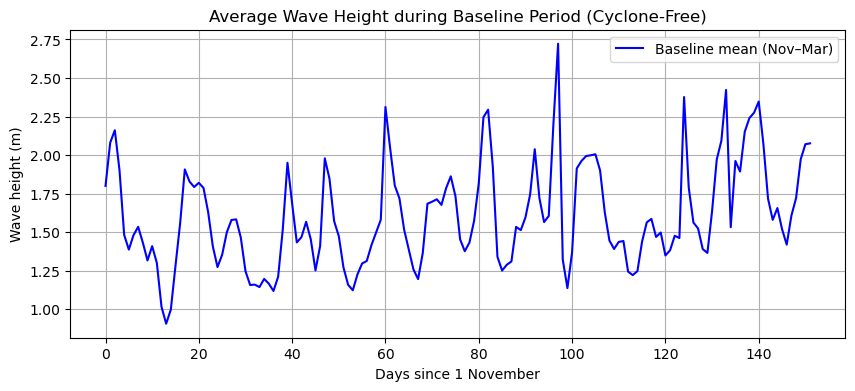

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(
    baseline_mean_wave.season_day,
    baseline_mean_wave,
    label="Baseline mean (Nov–Mar)",
    color="blue"
)

plt.xlabel("Days since 1 November")
plt.ylabel("Wave height (m)")
plt.title("Average Wave Height during Baseline Period (Cyclone-Free)")
plt.grid(True)
plt.legend()
plt.savefig("plots/baseline_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
wave_ts_fina = height_fina.mean(dim=("latitude", "longitude"))

print("Max wave height during cyclone Fina:", wave_ts_fina.max().values, "m")
wave_ts_alfred = height_alfred.mean(dim=("latitude", "longitude"))
print("Max wave height during cyclone Alfred:", wave_ts_alfred.max().values, "m")

print("Mean wave height during baseline period:", baseline_mean_wave.mean().values, "m")


Max wave height during cyclone Fina: 3.0927999019622803 m
Max wave height during cyclone Alfred: 8.970800399780273 m
Mean wave height during baseline period: 1.6052111838209002 m


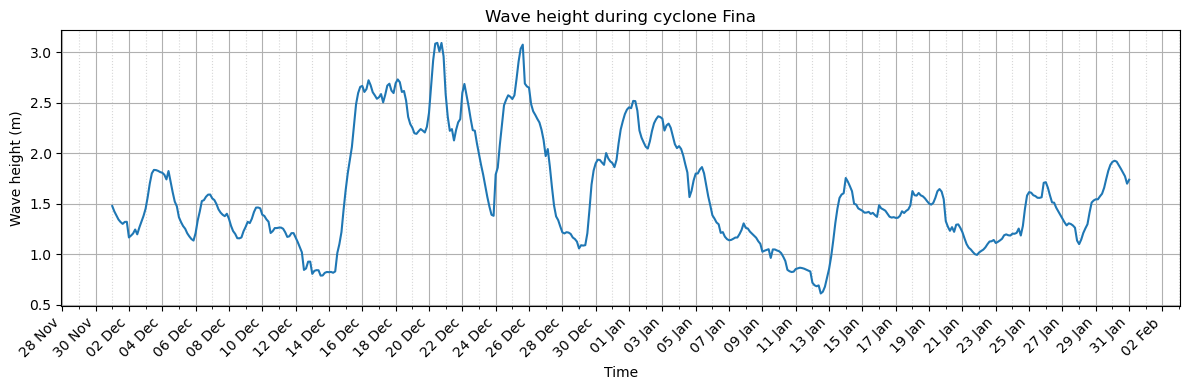

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))

wave_ts_fina.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wave height during cyclone Fina")
ax.set_ylabel("Wave height (m)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/fina_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

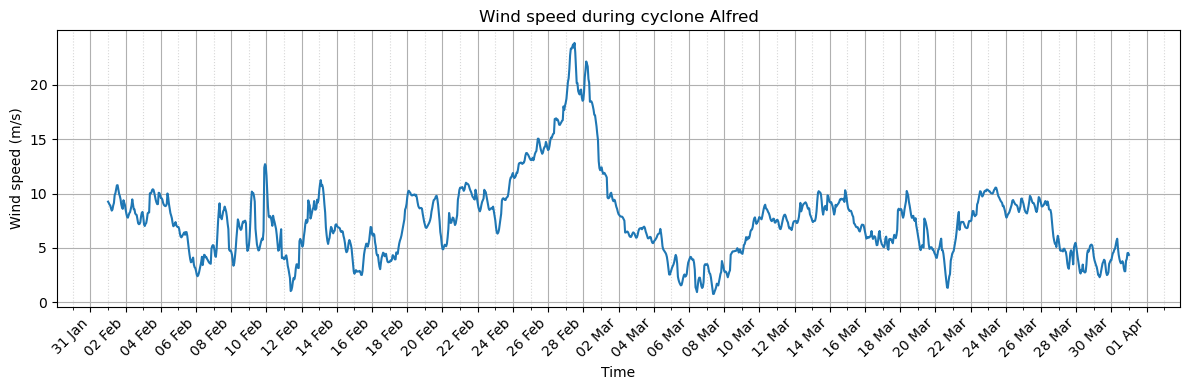

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))

wind_ts_alfred.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_title("Wind speed during cyclone Alfred")
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("Time")

ax.grid(True, which='major', linestyle='-')
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/alfred_wave_height.png", dpi=300, bbox_inches="tight")
plt.show()

## Combined analysis

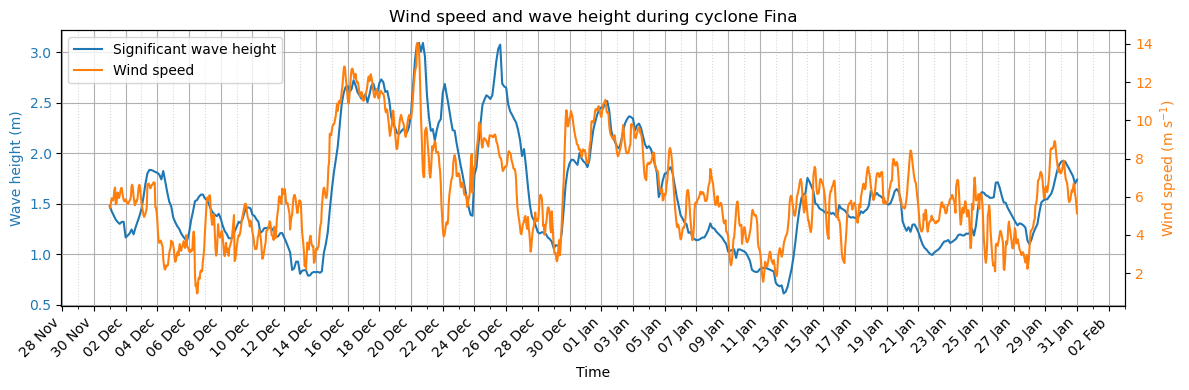

In [21]:
#Fina
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_fina.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_fina.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Fina")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.savefig("plots/fina_combined.png", dpi=300, bbox_inches="tight")
plt.show()


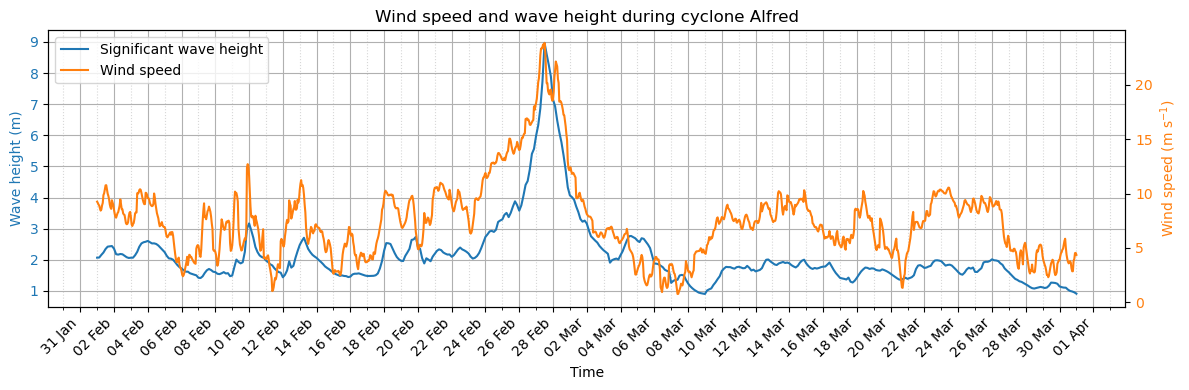

In [22]:
#Alfred
fig, ax_wave = plt.subplots(figsize=(12, 4))

# wave height (left y-axis)
wave_line, = wave_ts_alfred.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = wind_ts_alfred.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax_wave.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax_wave.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during cyclone Alfred")
ax_wave.set_xlabel("Time")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.savefig("plots/alfred_combined.png", dpi=300, bbox_inches="tight")
plt.show()


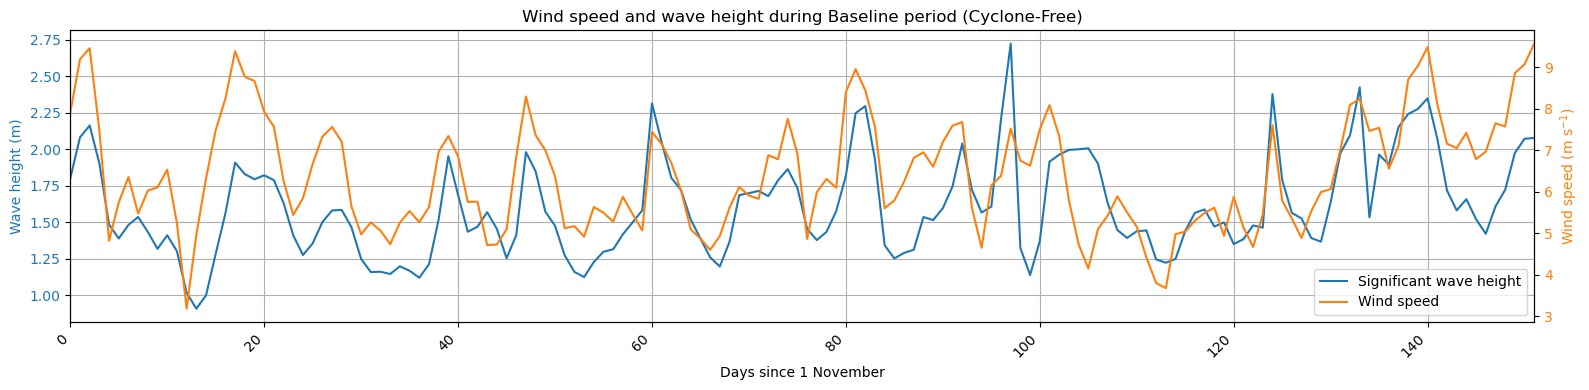

In [23]:
#baseline
fig, ax_wave = plt.subplots(figsize=(16, 4))

# wave height (left y-axis)
wave_line, = baseline_mean_wave.plot(
    ax=ax_wave,
    color="tab:blue",
    label="Significant wave height"
)

ax_wave.set_ylabel("Wave height (m)", color="tab:blue")
ax_wave.tick_params(axis="y", labelcolor="tab:blue")

# second y-axis for wind
ax_wind = ax_wave.twinx()

wind_line, = baseline_mean_wind.plot(
    ax=ax_wind,
    color="tab:orange",
    label="Wind speed"
)

ax_wind.set_ylabel("Wind speed (m s$^{-1}$)", color="tab:orange")
ax_wind.tick_params(axis="y", labelcolor="tab:orange")

# X-axis formatting
ax_wave.set_xlim(0, 151)
ax_wave.set_xlabel("Days since 1 November")

plt.setp(ax_wave.get_xticklabels(), rotation=45, ha="right")

# grid
ax_wave.grid(True, which="major", linestyle="-")
ax_wave.grid(True, which="minor", linestyle=":", alpha=0.5)

ax_wave.set_title("Wind speed and wave height during Baseline period (Cyclone-Free)")
ax_wave.set_xlabel("Days since 1 November")

# legend
lines = [wave_line, wind_line]
labels = [line.get_label() for line in lines]
ax_wave.legend(lines, labels, loc="lower right")

plt.tight_layout()
plt.savefig("plots/baseline_combined.png", dpi=300, bbox_inches="tight")
plt.show()



anomalies

In [24]:
def baseline_timeseries_for_event(event_ts, baseline_seasonal):
    """
    Map each event time step to the seasonally matched baseline value.
    """
    event_sd = add_season_day(event_ts).season_day
    baseline_for_event = baseline_seasonal.sel(season_day=event_sd)
    return xr.DataArray(
        baseline_for_event.values,
        coords=event_ts.coords,
        dims=event_ts.dims,
    )


def to_days_since_start(da):
    """
    Convert a time series to days since the first time step.
    """
    days = (da.time - da.time[0]) / np.timedelta64(1, "D")
    return da.assign_coords(days_since_start=days)

In [25]:
# wind
baseline_wind_fina_ts = baseline_timeseries_for_event(
    wind_ts_fina, baseline_mean_wind
)
baseline_wind_alfred_ts = baseline_timeseries_for_event(
    wind_ts_alfred, baseline_mean_wind
)

wind_anom_fina_ts = wind_ts_fina - baseline_wind_fina_ts
wind_anom_alfred_ts = wind_ts_alfred - baseline_wind_alfred_ts

wind_anom_fina_rel = to_days_since_start(wind_anom_fina_ts)
wind_anom_alfred_rel = to_days_since_start(wind_anom_alfred_ts)

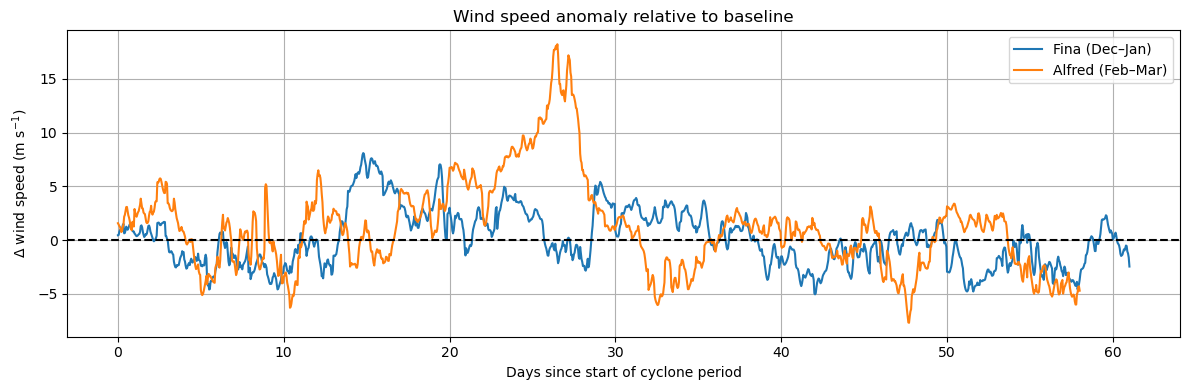

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wind_anom_fina_rel.days_since_start,
    wind_anom_fina_rel,
    label="Fina (Dec–Jan)",
    color="tab:blue",
)

ax.plot(
    wind_anom_alfred_rel.days_since_start,
    wind_anom_alfred_rel,
    label="Alfred (Feb–Mar)",
    color="tab:orange",
)

ax.axhline(0, color="black", linestyle="--")

ax.set_title("Wind speed anomaly relative to baseline")
ax.set_xlabel("Days since start of cyclone period")
ax.set_ylabel("Δ wind speed (m s$^{-1}$)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plots/wind_anomaly_timeseries_small.png", dpi=300)
plt.show()


In [29]:
# wave
baseline_wave_fina_ts = baseline_timeseries_for_event(
    wave_ts_fina, baseline_mean_wave
)

baseline_wave_alfred_ts = baseline_timeseries_for_event(
    wave_ts_alfred, baseline_mean_wave
)

wave_anom_fina_ts   = wave_ts_fina   - baseline_wave_fina_ts
wave_anom_alfred_ts = wave_ts_alfred - baseline_wave_alfred_ts

wave_anom_fina_rel   = to_days_since_start(wave_anom_fina_ts)
wave_anom_alfred_rel = to_days_since_start(wave_anom_alfred_ts)

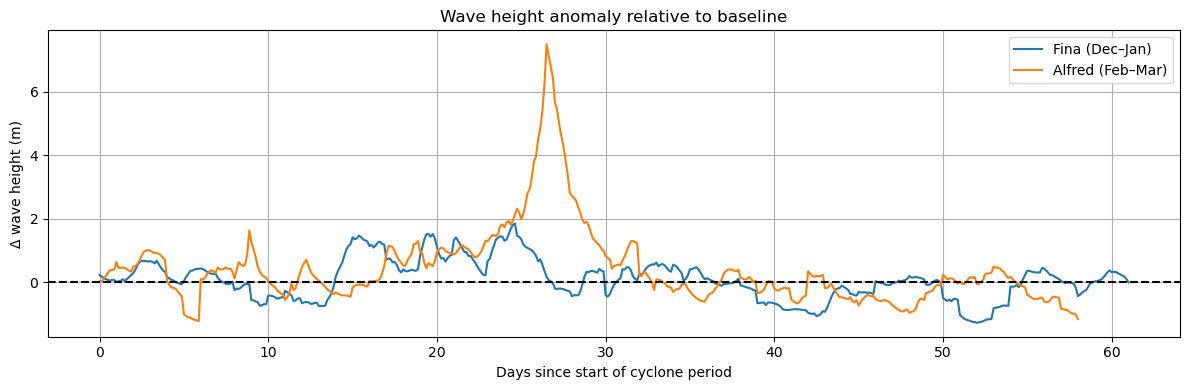

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave_anom_fina_rel.days_since_start,
    wave_anom_fina_rel,
    label="Fina (Dec–Jan)",
    color="tab:blue",
)

ax.plot(
    wave_anom_alfred_rel.days_since_start,
    wave_anom_alfred_rel,
    label="Alfred (Feb–Mar)",
    color="tab:orange",
)

ax.axhline(0, color="black", linestyle="--")

ax.set_title("Wave height anomaly relative to baseline")
ax.set_xlabel("Days since start of cyclone period")
ax.set_ylabel("Δ wave height (m)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plots/wave_anomaly_timeseries_small.png", dpi=300)
plt.show()